In [29]:
from modules.visualization import plot_waveforms
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture



In [3]:
import numpy as np
import pywt

def detect_spikes_wavelet_pywt(
    signal,
    fs,
    scale_ms=1.0,
    threshold_factor=4.0,
    min_distance_ms=1.0
):
    """
    Wavelet-based spike detection using PyWavelets (mexh wavelet).

    Parameters
    ----------
    signal : 1D array
        Neural voltage trace.
    fs : float
        Sampling frequency in Hz.
    scale_ms : float
        Wavelet scale in milliseconds (approx spike width).
    threshold_factor : float
        Threshold = threshold_factor * MAD.
    min_distance_ms : float
        Minimum refractory period between spikes.

    Returns
    -------
    spike_times : array
        Detected spike times in seconds.
    spike_indices : array
        Indices of detected spikes in the original signal.
    """

    # Convert ms → samples
    scale_samples = scale_ms * 1e-3 * fs
    min_distance = int(min_distance_ms * 1e-3 * fs)

    # PyWavelets expects scales as an array
    coeffs, _ = pywt.cwt(signal, scales=[scale_samples], wavelet='mexh')
    coeffs = coeffs[0]  # single scale

    # Robust noise estimate (MAD)
    sigma = np.median(np.abs(coeffs)) / 0.6745
    threshold = threshold_factor * sigma

    # Threshold crossings
    candidate_idx = np.where(np.abs(coeffs) > threshold)[0]

    # Enforce refractory period
    spike_indices = []
    last = -np.inf

    for idx in candidate_idx:
        if idx - last > min_distance:
            spike_indices.append(idx)
            last = idx

    spike_indices = np.array(spike_indices)
    spike_times = spike_indices / fs

    return spike_times, spike_indices

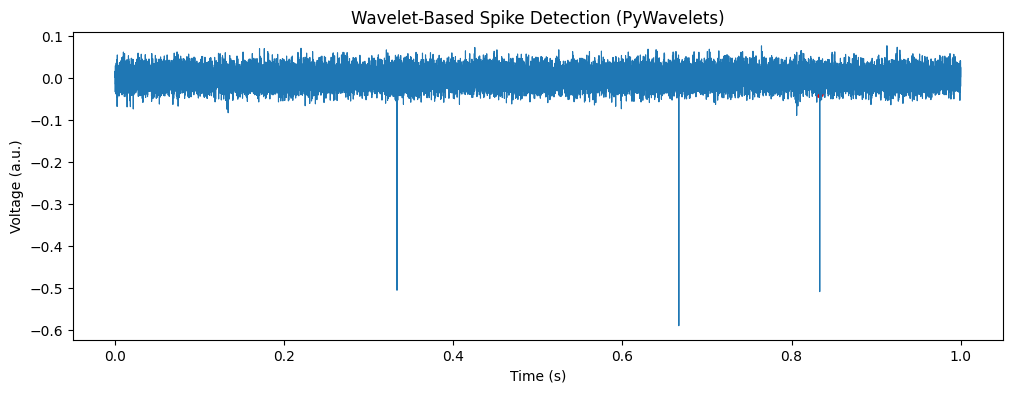

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fs = 30000
t = np.arange(0, 1, 1/fs)

# Fake spikes
signal = 0.02 * np.random.randn(len(t))
signal[10000] -= 0.5
signal[20000] -= 0.6
signal[25000] -= 0.55   # valid index

spike_times, spike_idx = detect_spikes_wavelet_pywt(signal, fs)

plt.figure(figsize=(12,4))
plt.plot(t, signal, linewidth=0.8)
plt.scatter(spike_times, signal[spike_idx], color='red', s=30)
plt.title("Wavelet-Based Spike Detection (PyWavelets)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (a.u.)")
plt.show()

In [8]:
spike_times

array([0.33293333, 0.83283333])

In [46]:
import numpy as np

n_traces = 100
length = 60
noise_std = 0.8  # adjust for more/less noise

t = np.linspace(0, 1, length)

def extracellular_spike(t):
    """
    Synthetic extracellular spike:
    - Negative trough (Gaussian)
    - Small positive rebound
    """
    trough = -30 * np.exp(-((t - 0.35)**2) / 0.0009)
    rebound = 8 * np.exp(-((t - 0.55)**2) / 0.003)
    return trough + rebound

base = extracellular_spike(t)

def random_warp(sig):
    """Randomly stretch/compress spike duration."""
    stretch = np.random.uniform(0.8, 1.25)
    new_len = int(len(sig) * stretch)
    t_old = np.linspace(0, 1, len(sig))
    t_new = np.linspace(0, 1, new_len)
    return np.interp(t_new, t_old, sig)

def center_on_trough(sig, length):
    """Center the negative peak in the window."""
    trough_idx = np.argmin(sig)
    center = length // 2
    padded = np.zeros(length)

    start = center - trough_idx
    end = start + len(sig)

    s0 = max(0, start)
    s1 = min(length, end)
    sig0 = max(0, -start)
    sig1 = sig0 + (s1 - s0)

    padded[s0:s1] = sig[sig0:sig1]
    return padded

aps = []

for _ in range(n_traces):
    # 1. Warp duration
    warped = random_warp(base)

    # 2. Amplitude variability
    amp = np.random.uniform(0.7, 1.4)
    warped *= amp

    # 3. Center on negative peak
    centered = center_on_trough(warped, length)

    # 4. Add noise
    noisy = centered + np.random.normal(0, noise_std, length)

    aps.append(noisy)

aps = np.array(aps)
aps.shape

(100, 60)

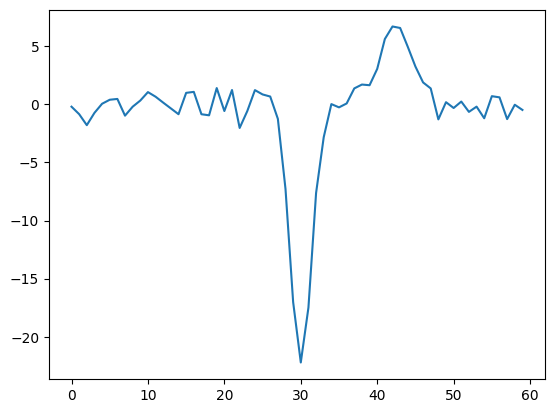

In [47]:
plt.plot(aps[0])

In [49]:
fs = 20000

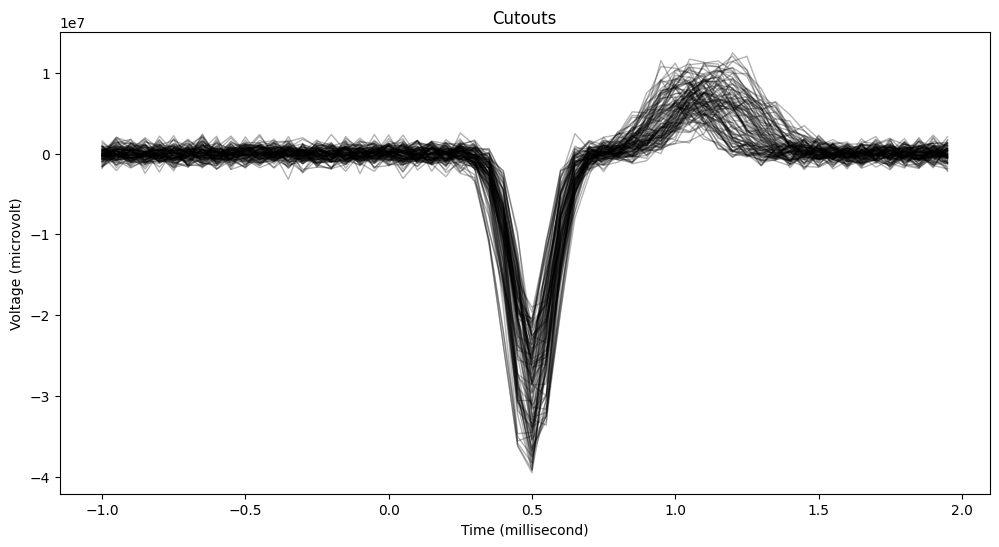

In [50]:
pre = 0.001 # 1 ms
post= 0.002 # 2 ms

plot_waveforms(aps, fs, pre, post)


In [51]:
scaler = StandardScaler()
scaled_cutouts = scaler.fit_transform(aps)

pca = PCA()
pca.fit(scaled_cutouts)
print(pca.explained_variance_ratio_)

[1.70731266e-01 8.37110218e-02 5.49539273e-02 4.19021129e-02
 3.83613059e-02 3.65190331e-02 3.50231471e-02 3.31976004e-02
 3.05207500e-02 2.82968690e-02 2.72199717e-02 2.58536788e-02
 2.42761876e-02 2.31107870e-02 2.18142808e-02 2.13041415e-02
 2.03452249e-02 1.87221857e-02 1.73967059e-02 1.67902557e-02
 1.56376841e-02 1.50074838e-02 1.40205561e-02 1.37309944e-02
 1.34128483e-02 1.30222339e-02 1.17484774e-02 1.10349094e-02
 1.05708860e-02 1.04182275e-02 9.22327295e-03 8.66394899e-03
 8.05592478e-03 7.55619913e-03 6.80916124e-03 6.49260496e-03
 6.23872540e-03 5.46926864e-03 5.05913123e-03 4.87497809e-03
 4.30979426e-03 4.06229367e-03 3.57409672e-03 2.95953705e-03
 2.78085982e-03 2.47072805e-03 2.09393654e-03 1.83601430e-03
 1.64868421e-03 1.37213345e-03 1.24794265e-03 1.09566117e-03
 8.13146801e-04 7.22889010e-04 6.08112353e-04 4.53913320e-04
 3.17542399e-04 2.34655702e-04 1.69511715e-04 1.30577798e-04]


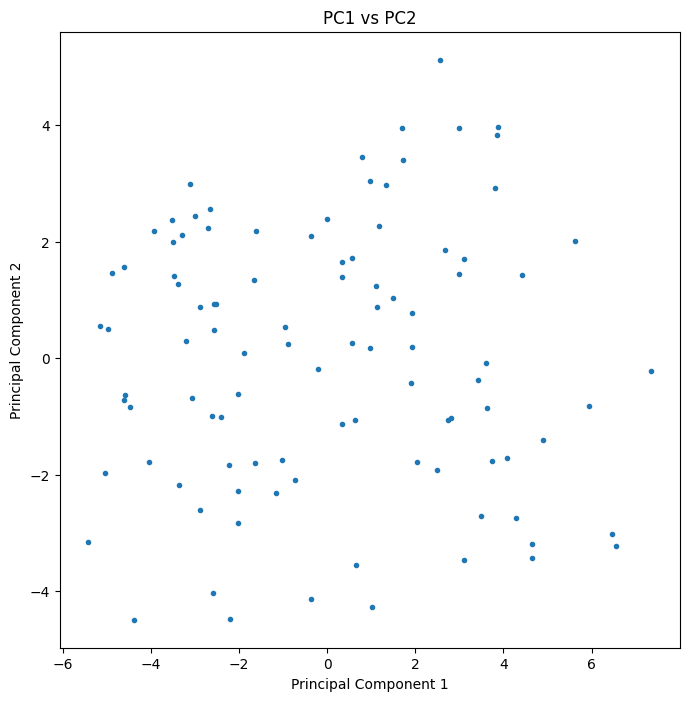

In [52]:
pca.n_components = 2
transformed = pca.fit_transform(scaled_cutouts)

_ = plt.figure(figsize=(8,8))
_ = plt.plot(transformed[:,0], transformed[:,1],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 2')
_ = plt.title('PC1 vs PC2')

plt.show()

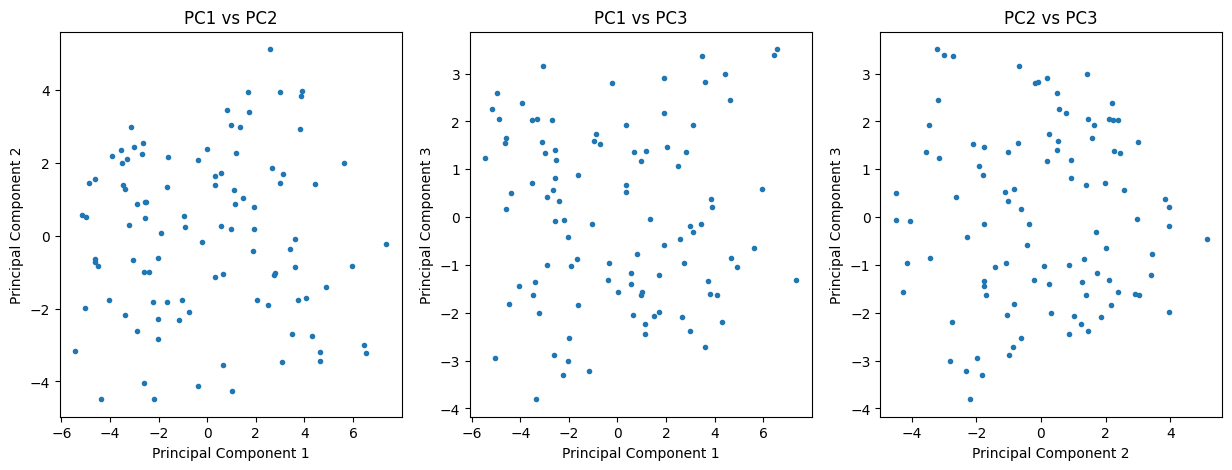

In [53]:
pca.n_components = 3
transformed_3d = pca.fit_transform(scaled_cutouts)

_ = plt.figure(figsize=(15,5))
_ = plt.subplot(1, 3, 1)
_ = plt.plot(transformed_3d[:,0], transformed_3d[:,1],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 2')
_ = plt.title('PC1 vs PC2')
_ = plt.subplot(1, 3, 2)
_ = plt.plot(transformed_3d[:,0], transformed_3d[:,2],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 3')
_ = plt.title('PC1 vs PC3')
_ = plt.subplot(1, 3, 3)
_ = plt.plot(transformed_3d[:,1], transformed_3d[:,2],'.')
_ = plt.xlabel('Principal Component 2')
_ = plt.ylabel('Principal Component 3')
_ = plt.title('PC2 vs PC3')
plt.show()

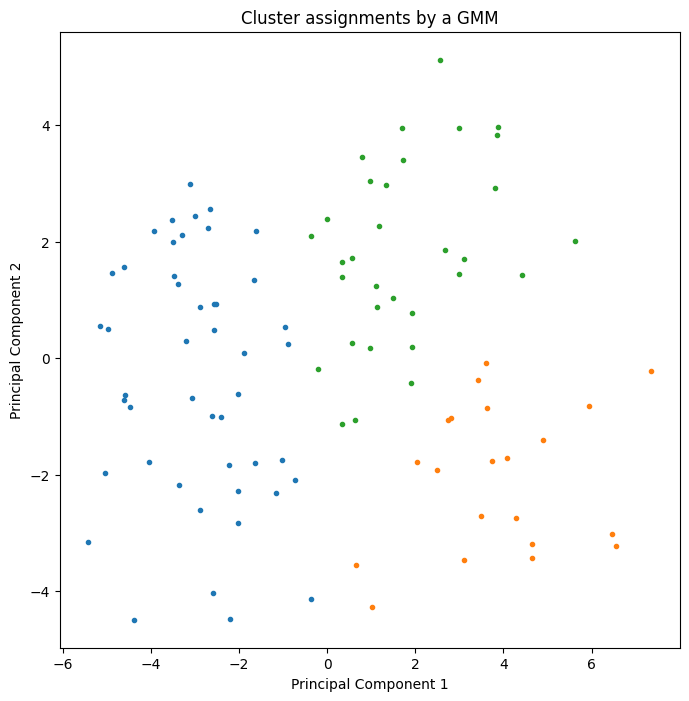

In [54]:
# Clustering
n_components = 3
gmm = GaussianMixture(n_components=n_components, n_init=10)
labels = gmm.fit_predict(transformed)

_ = plt.figure(figsize=(8,8))
for i in range(n_components):
    idx = labels == i
    _ = plt.plot(transformed[idx,0], transformed[idx,1],'.')
    _ = plt.title('Cluster assignments by a GMM')
    _ = plt.xlabel('Principal Component 1')
    _ = plt.ylabel('Principal Component 2')
    _ = plt.axis('tight')
plt.show()

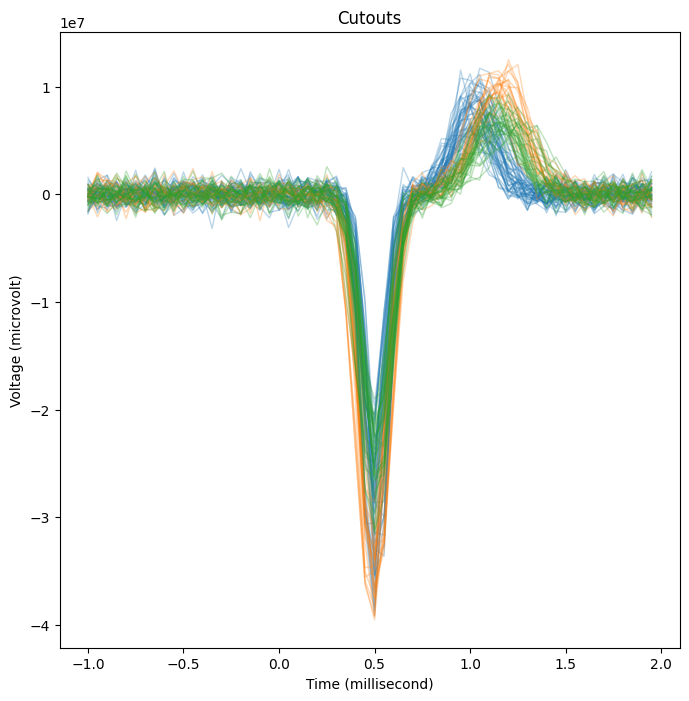

In [55]:
_ = plt.figure(figsize=(8,8))
for i in range(n_components):
    idx = labels == i
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i]
    plot_waveforms(aps[idx,:], fs, pre, post, n=100, color=color, show=False)
plt.show()

In [56]:
import umap
